# Credit Score Classification

In [324]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score
from sklearn.tree import DecisionTreeClassifier
import re
import matplotlib.pyplot as plt
import numpy as np


In [325]:
#Read Dataset
df= pd.read_csv('dataset/train.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

/var/folders/n2/hbm_2n0n7k56fnqv2q9mgbkm0000gn/T/ipykernel_23641/1022397046.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('dataset/train.csv')


In [326]:
df.head()


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## 1. Data Cleaning

Drop Duplicates

drop columns with potential multicolinearty

Check missing values


In [327]:
df_cleaned = df.copy()
df_cleaned.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

We could either replacing the missing values with means or medians of the columns, but there are 11 percent of categorical missing values in column "Type of Loans", which is not easy to fill missing values as means or medians. Thus, to reduce artifical intervention with the values, we decided to first try dropping the rows with missing values. 

In [328]:
# Check missing values
missing_values = df_cleaned.isna().sum()
missing_rate = missing_values / len(df_cleaned) * 100
missing_rate

ID                           0.000
Customer_ID                  0.000
Month                        0.000
Name                         9.985
Age                          0.000
SSN                          0.000
Occupation                   0.000
Annual_Income                0.000
Monthly_Inhand_Salary       15.002
Num_Bank_Accounts            0.000
Num_Credit_Card              0.000
Interest_Rate                0.000
Num_of_Loan                  0.000
Type_of_Loan                11.408
Delay_from_due_date          0.000
Num_of_Delayed_Payment       7.002
Changed_Credit_Limit         0.000
Num_Credit_Inquiries         1.965
Credit_Mix                   0.000
Outstanding_Debt             0.000
Credit_Utilization_Ratio     0.000
Credit_History_Age           9.030
Payment_of_Min_Amount        0.000
Total_EMI_per_month          0.000
Amount_invested_monthly      4.479
Payment_Behaviour            0.000
Monthly_Balance              1.200
Credit_Score                 0.000
dtype: float64

Since each row represents a customer, to ensure same person does not appear in the dataset more than once, we dropped any duplicates in the dataset.

In [329]:
# Drop duplicates 
df_cleaned.drop_duplicates


<bound method DataFrame.drop_duplicates of             ID Customer_ID     Month           Name   Age          SSN  \
0       0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265   
1       0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265   
2       0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265   
3       0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265   
4       0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265   
...        ...         ...       ...            ...   ...          ...   
99995  0x25fe9  CUS_0x942c     April          Nicks    25  078-73-5990   
99996  0x25fea  CUS_0x942c       May          Nicks    25  078-73-5990   
99997  0x25feb  CUS_0x942c      June          Nicks    25  078-73-5990   
99998  0x25fec  CUS_0x942c      July          Nicks    25  078-73-5990   
99999  0x25fed  CUS_0x942c    August          Nicks    25  078-73-5990   

      Occupation Annual_Income  Monthly_Inhand_Salary  Num_Bank_Acco

We then drop the identity columns 'ID','Customer_ID', 'Name', 'SSN'. 'Month' represents the reporting month of the credit score. Since we are not interested in time series related analysis in this project, we dropped 'Month' and treated each row as a sample point.

In [330]:
# Drop the personal information as columns
drop_columns = ['ID','Customer_ID','Month','Name','SSN']
df_cleaned = df_cleaned.drop(drop_columns, axis = 1)
df_cleaned.shape


(100000, 23)

### 1.1 Numerical Data

In [331]:
# The numeric columns: 8
numerical_columns = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate','Delay_from_due_date', 'Num_of_Loan', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly',
    'Monthly_Balance', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries']

len(numerical_columns)

16

In [332]:
df_cleaned.select_dtypes('number').columns

Index(['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries',
       'Credit_Utilization_Ratio', 'Total_EMI_per_month'],
      dtype='object')

In [333]:
# format the columns
# replace spaces with underscores
df_cleaned['Age'] = df_cleaned['Age'].str.replace(r'_', '', regex=True).astype(int)
df_cleaned['Num_of_Loan'] = df_cleaned['Num_of_Loan'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Annual_Income'] = df_cleaned['Annual_Income'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Outstanding_Debt'] = df_cleaned['Outstanding_Debt'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Monthly_Balance'] = df_cleaned['Monthly_Balance'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Num_of_Delayed_Payment'] = df_cleaned['Num_of_Delayed_Payment'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Amount_invested_monthly'] = df_cleaned['Amount_invested_monthly'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Changed_Credit_Limit'] = df_cleaned['Changed_Credit_Limit'].str.replace(r'_', '', regex=True).replace('', np.nan).astype(float)

In [334]:
# Convert Data Types: Ensure numeric format
df_cleaned[numerical_columns] = df_cleaned[numerical_columns].apply(
    pd.to_numeric, errors='coerce'
)

# Drop all rows of age less than 0
df_cleaned = df_cleaned[(df_cleaned['Age'] >= 0) & (df_cleaned['Age'] <= 100)]

# Drop all the num of loans less than 0
df_cleaned = df_cleaned[df_cleaned['Num_of_Loan']>=0]

# Reset all negative Num_Bank_Accounts to 0
df_cleaned.loc[df_cleaned['Num_Bank_Accounts']<0,'Num_Bank_Accounts'] = 0

# Reset all negative Num_of_Delayed_Payment to 0
df_cleaned.loc[df_cleaned['Num_of_Delayed_Payment']<0,'Num_of_Delayed_Payment'] = 0

#Convert Credit_History_Age to a float number of days
def age2days(text, years=0, months=0):
    # Validate and handle empty or invalid input
    if not text or not isinstance(text, str):
        return 0  # Return 0 if text is empty or invalid
    
    days_in_year = 365.25
    days_in_month = 30.44

    years_match = re.search(r'(\d+)\s*Years?', text, re.IGNORECASE)
    months_match = re.search(r'(\d+)\s*Months?', text, re.IGNORECASE)

    years = int(years_match.group(1)) if years_match else 0
    months = int(months_match.group(1)) if months_match else 0

    return int((years * days_in_year) + (months * days_in_month))

df_cleaned['Credit_History_Age'] = df_cleaned['Credit_History_Age'].apply(age2days)





In [335]:
df_cleaned.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,93453.000000,9.345300e+04,79425.000000,93453.000000,93453.000000,93453.000000,93453.000000,93453.000000,86926.000000,91494.000000,91619.000000,93453.000000,93453.000000,93453.000000,93453.000000,89277.000000,9.075800e+04
mean,33.321327,1.769088e+05,4196.527620,17.124308,22.496324,72.428665,7.110633,21.083411,31.085832,10.394718,27.855161,1427.271573,32.288767,6120.638888,1403.242348,634.783092,-3.305494e+22
std,10.780162,1.432738e+06,3184.977425,117.537506,129.094718,467.118366,59.869060,14.859932,226.535397,6.795519,193.422923,1156.253050,5.116466,3478.919383,8300.761260,2036.679277,3.319238e+24
min,14.000000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,0.000000,-5.000000,0.000000,-6.480000,0.000000,0.230000,20.000000,0.000000,0.000000,0.000000,-3.333333e+26
25%,24.000000,1.945750e+04,1626.525000,3.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.330000,3.000000,566.080000,28.061048,3469.000000,30.306460,74.554174,2.698815e+02
50%,33.000000,3.757782e+04,3095.905000,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.410000,6.000000,1166.470000,32.309627,6331.000000,69.268455,135.961622,3.363816e+02
75%,42.000000,7.281788e+04,5961.637500,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.880000,9.000000,1948.980000,36.503156,8887.000000,161.484662,265.946990,4.693458e+02
max,100.000000,2.419806e+07,15204.633333,1798.000000,1499.000000,5797.000000,1496.000000,67.000000,4397.000000,36.490000,2597.000000,4998.070000,50.000000,12296.000000,82331.000000,10000.000000,1.602041e+03


In [336]:
def plot_boxplots(df):
    """
    Plots a boxplot for each column in the DataFrame.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with columns to plot.
    """

    # Plot each column
    for column in numerical_columns:
        plt.figure(figsize=(4, 3))
        sns.boxplot(data=df, x=column, color='lightblue')
        plt.title(f'Boxplot for {column}', fontsize=14)
        plt.xlabel(column, fontsize=12)
        plt.ylabel('Value', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

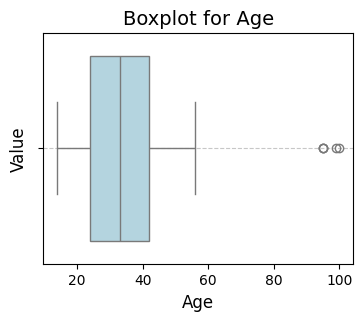

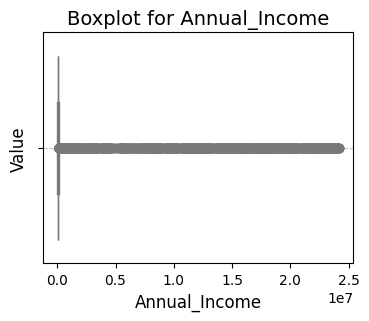

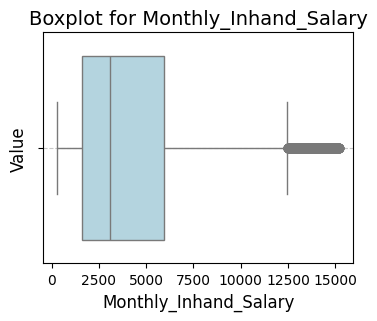

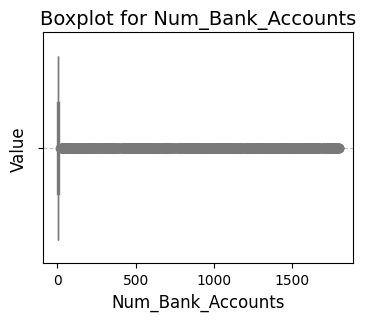

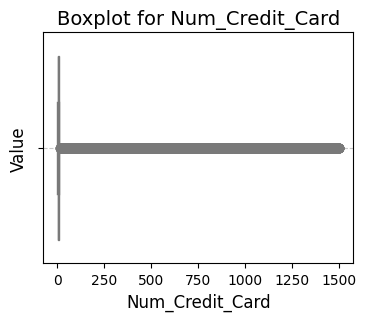

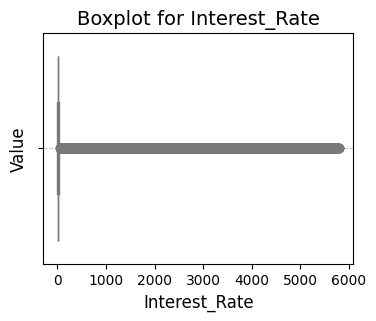

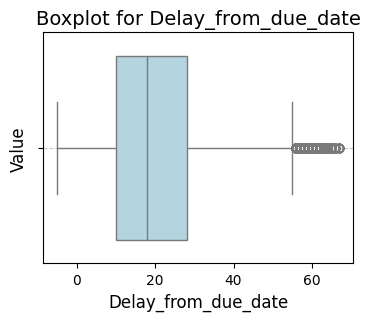

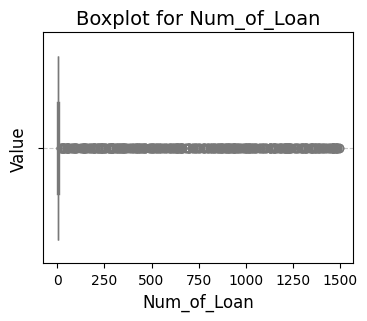

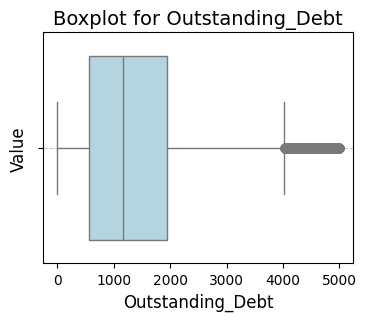

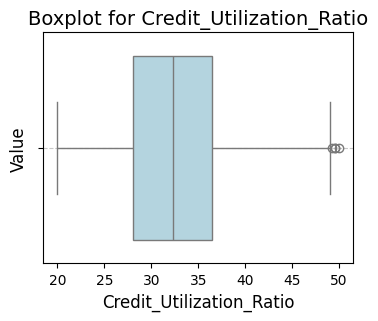

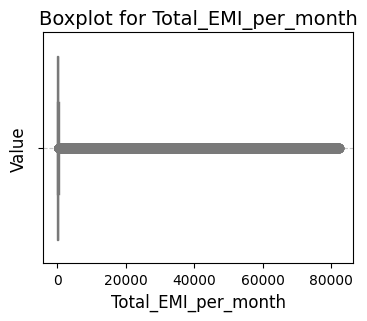

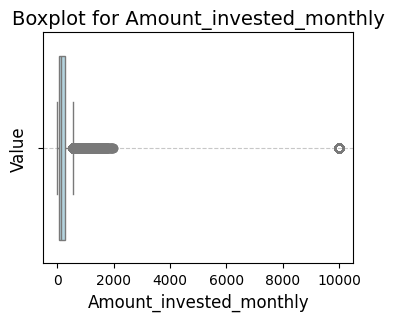

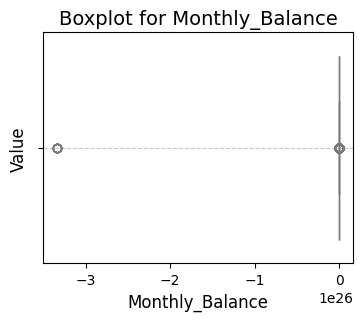

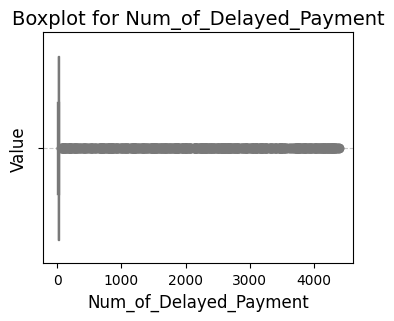

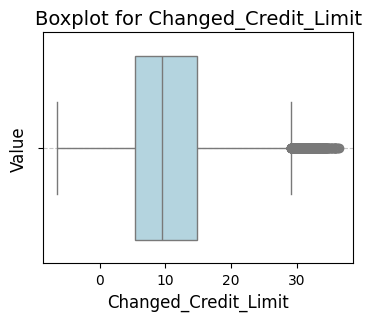

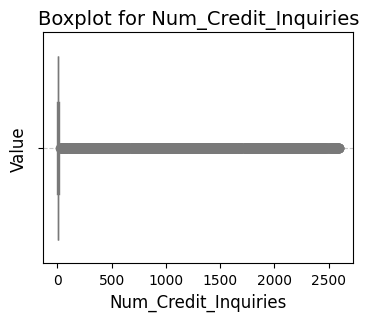

In [337]:
plot_boxplots(df_cleaned[numerical_columns])


In [338]:
# Remove Outliers: Clip to 1st and 99th percentile
for column in numerical_columns:
    lower = df_cleaned[column].quantile(0.01)
    upper = df_cleaned[column].quantile(0.99)
    df_cleaned[column] = df_cleaned[column].clip(lower, upper)

In [339]:
def drop_outliers_zscore(df, threshold=3):
    
    # Select only numerical columns
    numerical_columns = df.select_dtypes(include=['number'])

    # Compute Z-scores
    z_scores = np.abs((numerical_columns - numerical_columns.mean()) / numerical_columns.std())

    # Keep rows where all Z-scores are within the threshold
    filtered_df = df[(z_scores < threshold).all(axis=1)]
    
    return filtered_df

In [340]:
df_cleaned = drop_outliers_zscore(df_cleaned, threshold=3)
df_cleaned.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,55702.000000,55702.000000,55702.000000,55702.000000,55702.000000,55702.000000,55702.000000,55702.000000,55702.000000,55702.000000,55702.000000,55702.000000,55702.000000,55702.000000,55702.000000,55702.000000,55702.000000
mean,33.212542,47198.114152,3923.665310,5.512549,6.410273,16.792952,3.610445,21.353937,13.593605,10.507110,6.378012,1442.879165,32.187027,6067.993501,204.430275,183.994345,384.301803
std,10.785780,34537.788243,2872.619048,3.800029,13.242524,38.903405,2.462895,14.837691,6.316860,6.742771,11.960313,1158.845864,5.029959,3473.130212,1236.593584,177.815319,180.961130
min,14.000000,7534.185000,531.894517,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.570000,0.000000,27.630000,22.738761,0.000000,0.000000,16.881510,67.731796
25%,24.000000,19041.480000,1597.417500,4.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.420000,3.000000,577.390000,27.999609,3439.000000,29.565003,70.253155,268.369394
50%,33.000000,35578.455000,2971.761337,6.000000,5.000000,14.000000,3.000000,18.000000,14.000000,9.500000,6.000000,1181.115000,32.212713,6270.000000,65.779177,124.882668,332.573541
75%,42.000000,68131.800000,5649.093333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,15.100000,9.000000,1985.590000,36.402573,8826.000000,144.598635,226.524865,452.953005
max,55.000000,176044.040000,13680.136667,148.000000,317.000000,1037.000000,9.000000,61.000000,27.000000,28.840000,385.000000,4807.650000,42.445379,12296.000000,22898.000000,1473.852485,1026.231998


### 1.2 Categorical Data

In [342]:
# Handle Missing Values: drop missing values for categorical variables
df_cleaned = df_cleaned.dropna()

In [343]:
#Replace the '_______' value in the Occupation field with Other
df_cleaned['Occupation'] = df_cleaned['Occupation'].replace('_______', 'Other')

#Correct Typo
df_cleaned['Payment_of_Min_Amount'] = df_cleaned['Payment_of_Min_Amount'].str.replace('NM', 'No')

#Drop Typo
df_cleaned = df_cleaned[df_cleaned['Payment_Behaviour']!='!@9#%8']

In [344]:
# hasn't done processing yet, drop for now

df_cleaned.drop(columns=['Type_of_Loan'],inplace=True)
df_cleaned.drop(columns=['Credit_Mix'],inplace=True)

## 2. Data Visualization

/var/folders/n2/hbm_2n0n7k56fnqv2q9mgbkm0000gn/T/ipykernel_23641/1147980377.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df_cleaned['Credit_Score'],palette="mako")


(array([    0.,  5000., 10000., 15000., 20000., 25000., 30000.]),
 [Text(0.0, 0, '0'),
  Text(5000.0, 0, '5000'),
  Text(10000.0, 0, '10000'),
  Text(15000.0, 0, '15000'),
  Text(20000.0, 0, '20000'),
  Text(25000.0, 0, '25000'),
  Text(30000.0, 0, '30000')])

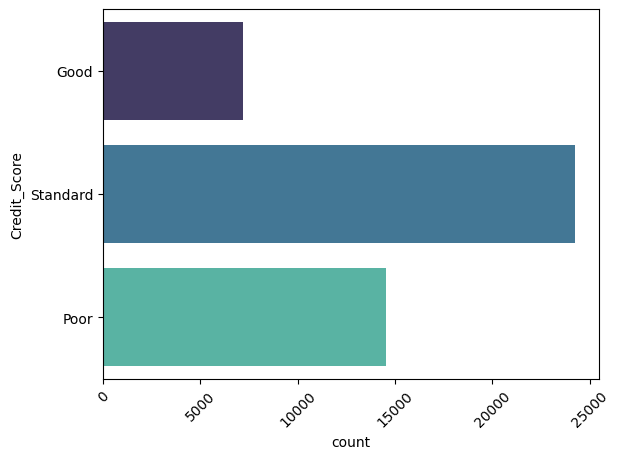

In [345]:
sns.countplot(df_cleaned['Credit_Score'],palette="mako")
plt.xticks(rotation=45)

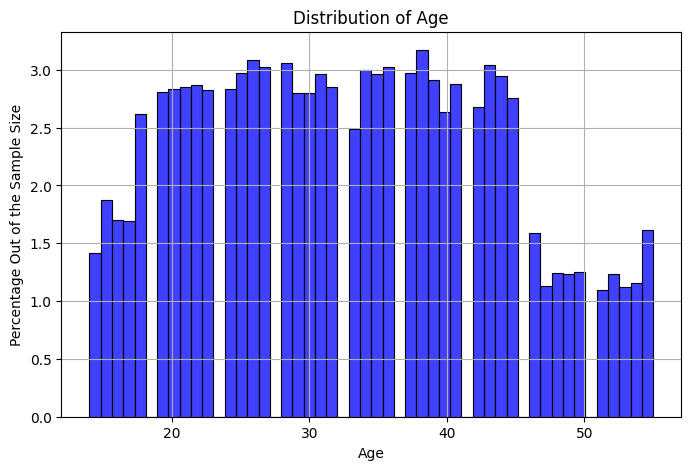

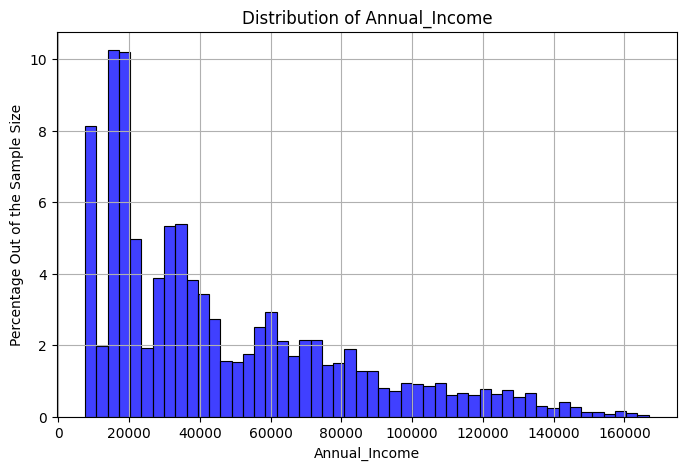

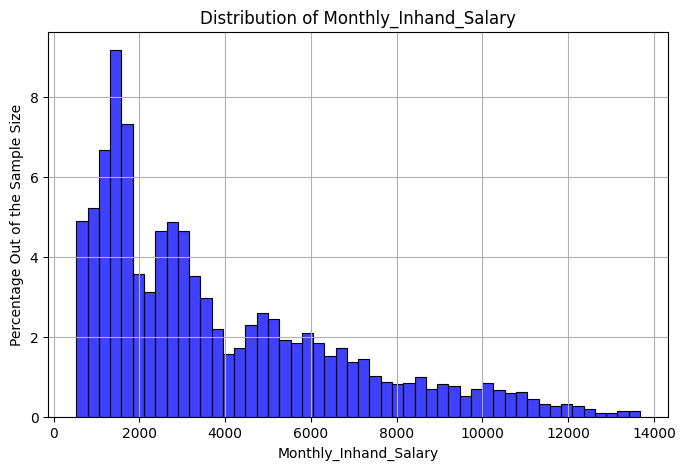

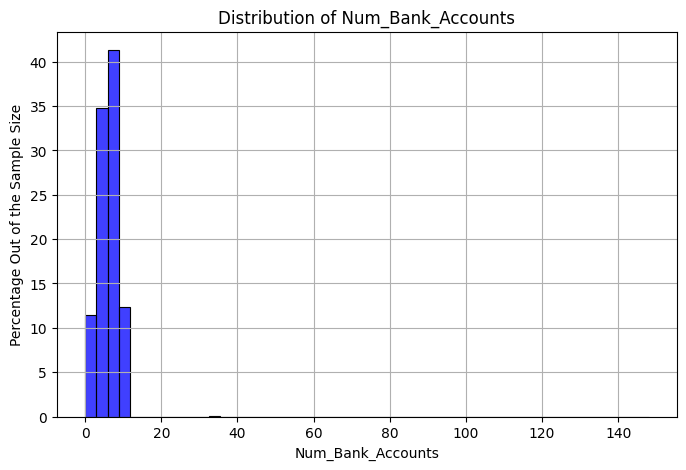

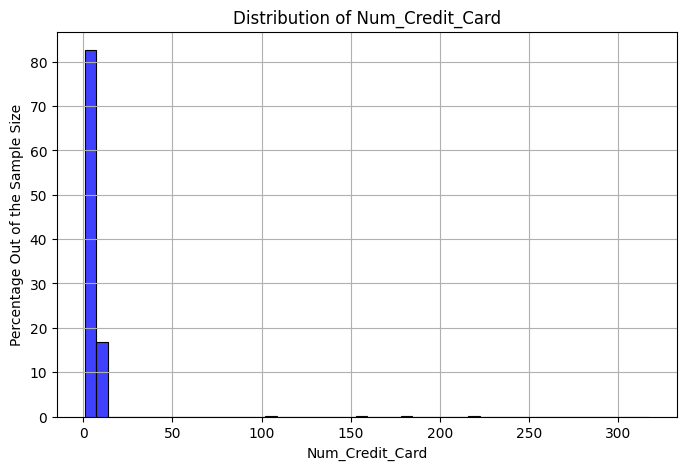

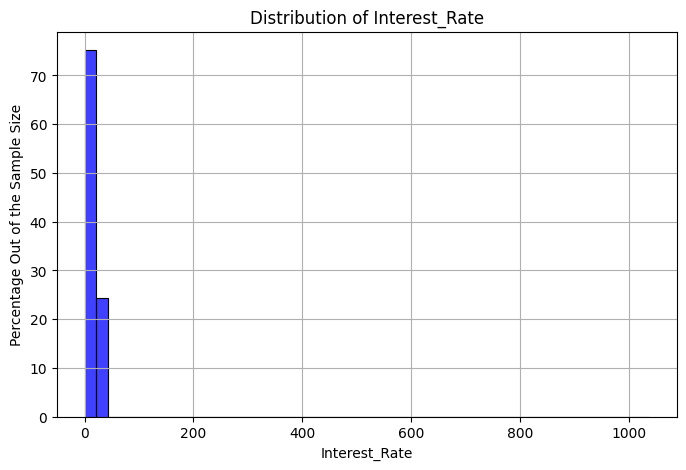

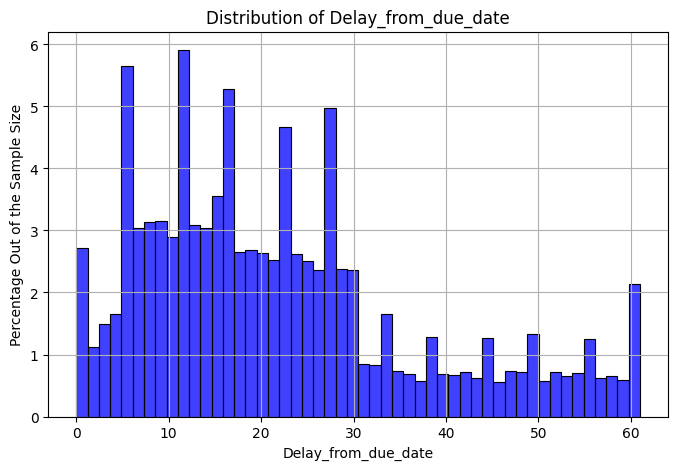

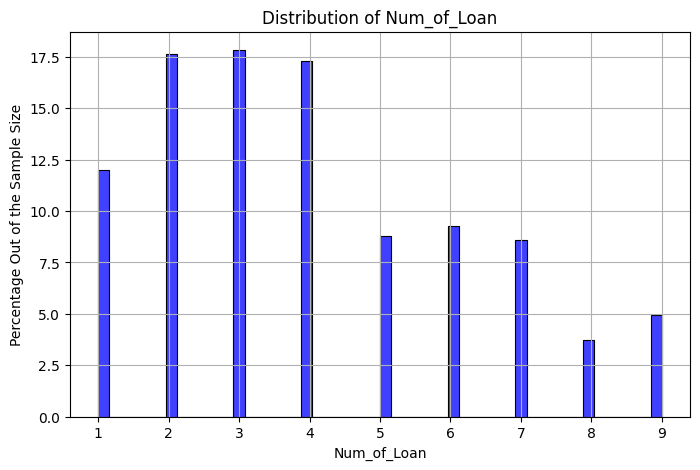

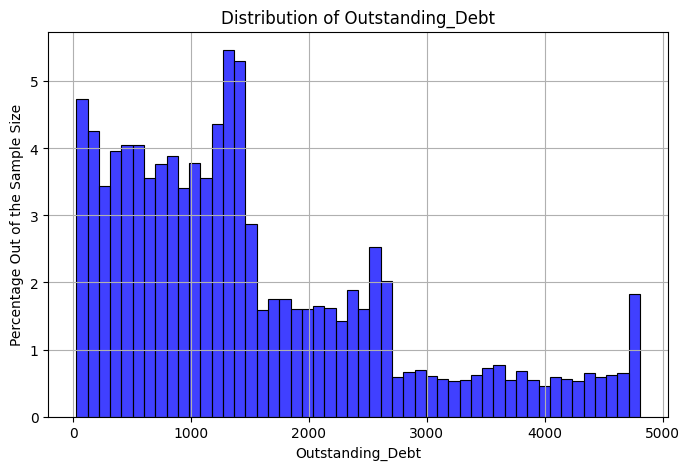

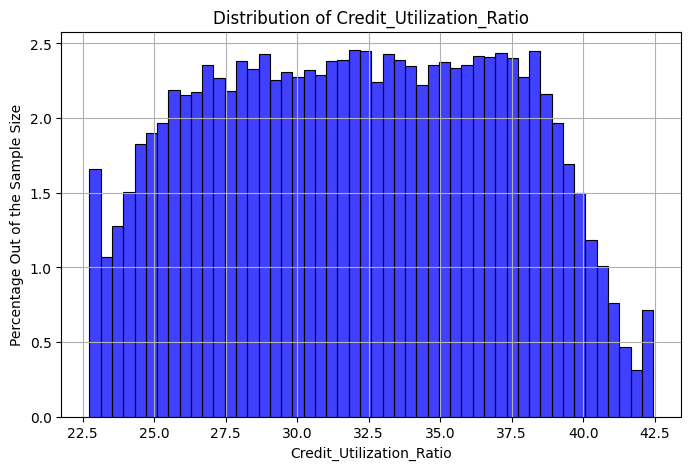

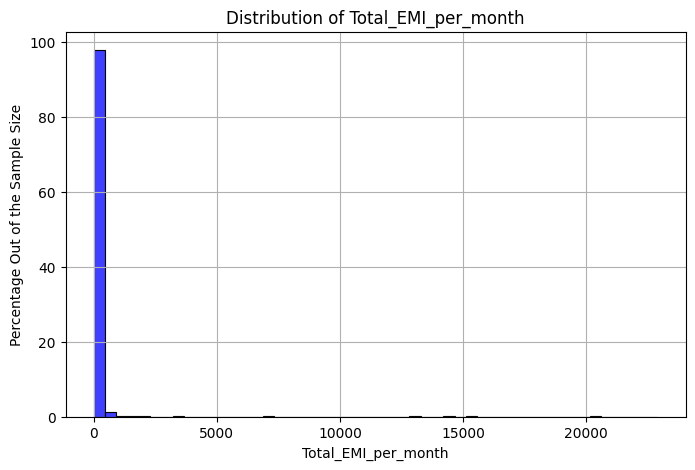

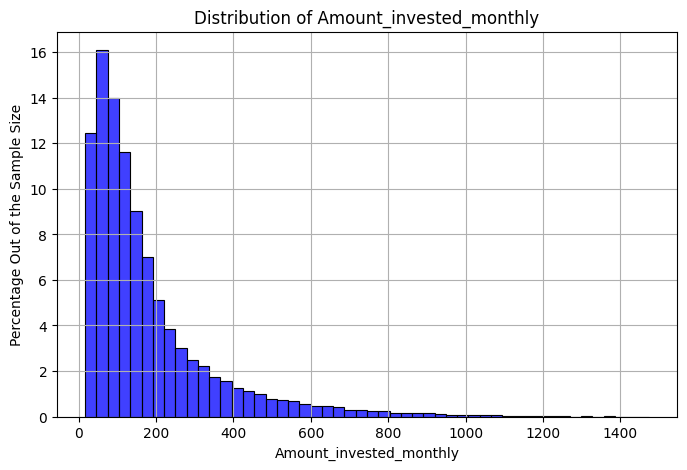

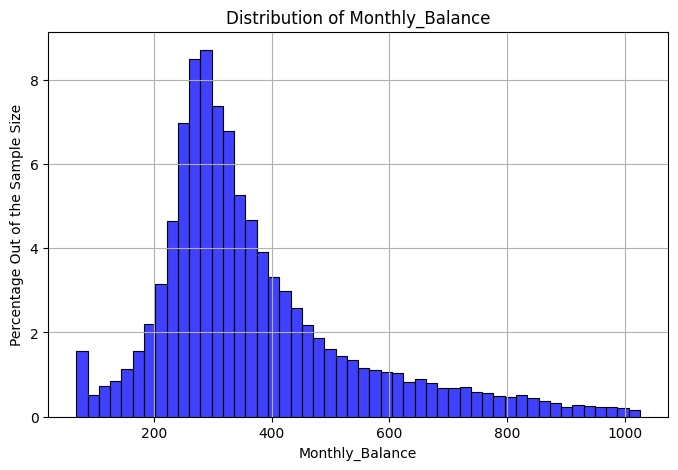

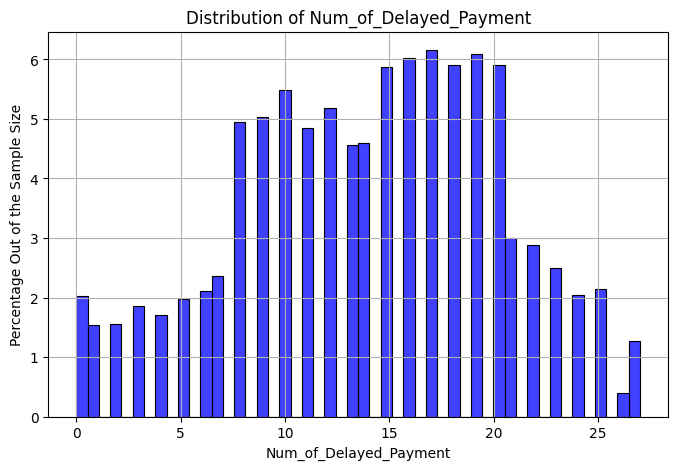

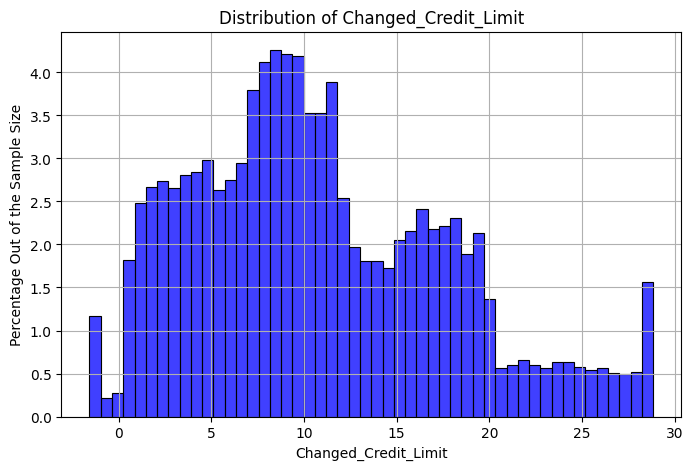

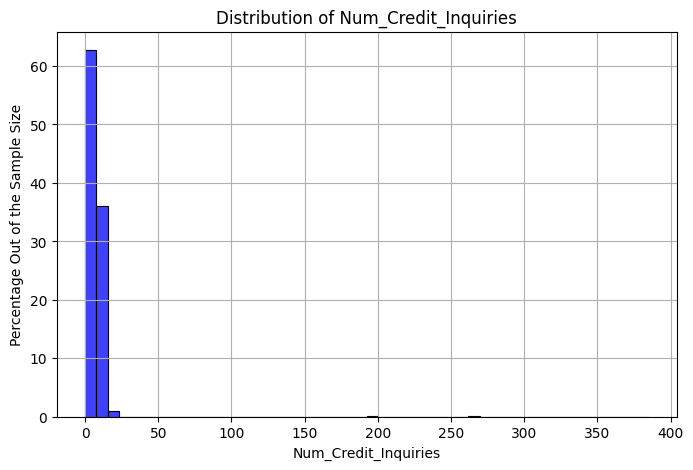

In [360]:
# Set up visualizations
for numerical_column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_cleaned[numerical_column],
                 stat= 'percent', 
                 kde=False, 
                 bins=50, 
                 color='blue', 
                 edgecolor='black')
    plt.title(f'Distribution of {numerical_column}')
    plt.xlabel(numerical_column)
    plt.ylabel('Percentage Out of the Sample Size')
    plt.grid(True)
    plt.show()


## 3. Feature Engineering

### 3.1 Encoding

In [347]:
df_final = df_cleaned.copy()
df_final.head().T

,0,6,7,8,9
Age,23,23,23,28,28
Occupation,Scientist,Scientist,Scientist,Other,Teacher
Annual_Income,19114.12,19114.12,19114.12,34847.84,34847.84
Monthly_Inhand_Salary,1824.843333,1824.843333,1824.843333,3037.986667,3037.986667
Num_Bank_Accounts,3.0,3.0,3.0,2.0,2.0
Num_Credit_Card,4.0,4.0,4.0,4.0,4.0
Interest_Rate,3.0,3.0,3.0,6.0,6.0
Num_of_Loan,4.0,4.0,4.0,1.0,1.0
Delay_from_due_date,3,3,3,3,7
Num_of_Delayed_Payment,7.0,8.0,6.0,4.0,1.0


In [348]:
df_final['Payment_of_Min_Amount'] = pd.get_dummies(df_final['Payment_of_Min_Amount'], columns=['Payment_of_Min_Amount'],prefix='Payment_of_Min_Amount',dtype=float,drop_first=True)

one_hot_encoding_columns = ['Occupation', 'Payment_Behaviour']
one_hot_encoded_columns = pd.get_dummies(df_final[one_hot_encoding_columns], dtype=float)
df_final = df_final.drop(columns=one_hot_encoding_columns).join(one_hot_encoded_columns)

In [349]:
X = df_final.drop(columns=['Credit_Score'])
X.head().T

,0,6,7,8,9
Age,23.000000,23.000000,23.000000,28.000000,28.000000
Annual_Income,19114.120000,19114.120000,19114.120000,34847.840000,34847.840000
Monthly_Inhand_Salary,1824.843333,1824.843333,1824.843333,3037.986667,3037.986667
Num_Bank_Accounts,3.000000,3.000000,3.000000,2.000000,2.000000
Num_Credit_Card,4.000000,4.000000,4.000000,4.000000,4.000000
Interest_Rate,3.000000,3.000000,3.000000,6.000000,6.000000
Num_of_Loan,4.000000,4.000000,4.000000,1.000000,1.000000
Delay_from_due_date,3.000000,3.000000,3.000000,3.000000,7.000000
Num_of_Delayed_Payment,7.000000,8.000000,6.000000,4.000000,1.000000
Changed_Credit_Limit,11.270000,11.270000,11.270000,5.420000,7.420000


In [350]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df_final['Credit_Score'])
y

array([0, 0, 2, ..., 1, 2, 2])

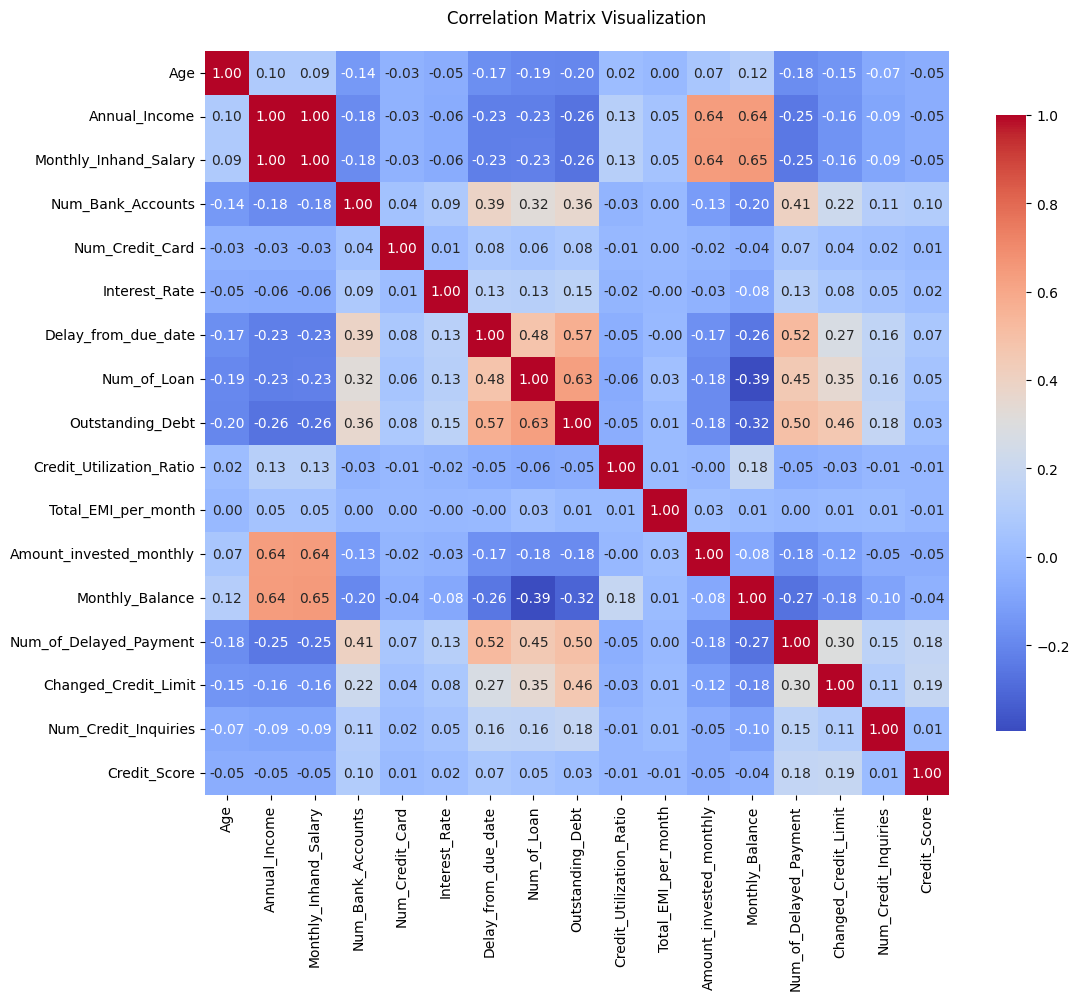

In [355]:
correlation_matrix = df_final[numerical_columns + ['Credit_Score']].corr()

# Plotting the correlation matrix with exact coefficients
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Display the correlation coefficients
    fmt=".2f",           # Format the coefficients to 2 decimal places
    cmap='coolwarm',     # Colormap
    square=True,         # Make the heatmap squares
    cbar_kws={'shrink': 0.8}  # Colorbar settings
)

# Adding title and axis labels
plt.title("Correlation Matrix Visualization", pad=20)
plt.xticks(rotation=90)  # Rotate x-axis labels
plt.yticks(rotation=0)   # Keep y-axis labels horizontal
plt.show()

In [ ]:
# Reduce dimensionality by dropping the variables to avoid multicolinearty
df_final = df_final.drop(['Monthly_Inhand_Salary'])

## 4. Machine Learning

In [352]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [353]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
print(mse,acc)

0.7817154038482443 0.6171322969888031


In [354]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}",mse)

Accuracy: 0.69 0.6528970540276117
